1. Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests as r
import os
from dotenv import load_dotenv

2. Через API достаю данные

In [2]:
load_dotenv()  # загружаются переменные из файла

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

visits_data = r.get(f'{API_URL}/visits', params={'begin': DATE_BEGIN, 'end': DATE_END})
regs_data = r.get(f'{API_URL}/registrations', params={'begin': DATE_BEGIN, 'end': DATE_END})

3. Дальше - подсчет конверсий:

- Собираю посещения

In [3]:
df_visits = pd.DataFrame(visits_data.json())

#checked for bots here
bots_check = df_visits['user_agent'].str.contains('bot', case= False, na= False, regex= False)
df_visits = df_visits[~bots_check]

#prepping date col
df_visits['datetime'] = pd.to_datetime(df_visits['datetime'])
df_visits = df_visits.sort_values(by= 'datetime', ascending= False)
df_visits['datetime'] = df_visits['datetime'].dt.floor('D')

#attribution
df_visits['rn'] = df_visits.groupby('visit_id').cumcount() +1
df_visits = df_visits[df_visits['rn'] < 2]
df_visits = df_visits.drop(columns= 'rn')

#finalizing
df_visits = df_visits.groupby(['datetime', 'platform']).count()

df_visits = df_visits.drop(columns= 'user_agent')
df_visits = df_visits.rename(columns= {'visit_id': 'visits'})

- Собираю регистрации

In [4]:
df_regs = pd.DataFrame(regs_data.json())

#prepping date col
df_regs['datetime'] = pd.to_datetime(df_regs['datetime'])
df_regs['datetime'] = df_regs['datetime'].dt.floor('D')

#finalizing
df_regs = df_regs.groupby(['datetime', 'platform']).count()

df_regs = df_regs.drop(columns= ['email', 'registration_type'])
df_regs = df_regs.rename(columns= {'user_id': 'registrations'})

- Объединяю датафреймы, чтобы получить конверсии

In [5]:
# merging visits and regs
df_conversion = pd.merge(
    df_visits, df_regs,
    how= 'outer',
    left_on= ['datetime', 'platform'],
    right_on= ['datetime', 'platform']
).reset_index()

#calculating conversion rates
df_conversion['conversion'] = (df_conversion['registrations'] / df_conversion['visits']) * 100

#formatting for da autotest
df_conversion = df_conversion.sort_values(by= 'datetime', ascending = True)
df_conversion = df_conversion.rename(columns= {'datetime': 'date_group'})

df_conversion.to_json("./conversion.json")

C:\Users\pepon\AppData\Local\Temp\ipykernel_12156\3930125258.py:16: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_conversion.to_json("./conversion.json")


4. Собираю данные по рекламе

- Винимаю данные, нормализую даты

In [6]:
df_ads_basic = pd.read_csv("./ads.csv")

df_ads_basic['date'] = pd.to_datetime(df_ads_basic['date'])
df_ads_basic['date'] = df_ads_basic['date'].dt.floor('D')
df_ads_basic = df_ads_basic.rename(columns= {'date': 'date_group'})

- На всякий случай завожу новую переменную под датафрейм с конверсиями, чтобы не попортить уже собранный фрейм такими командами как df.drop()
- Сбрасываю индекс
- Нормализую даты и подготавливаю датафрейм

In [7]:
df_visreg = df_conversion

df_visreg['date_group'] = pd.to_datetime(df_visreg['date_group'])
df_visreg = df_visreg.drop(columns= ['conversion', 'platform'])
df_visreg = df_visreg.groupby('date_group').sum().reset_index()

- Объединяю датафреймы
- Убираю лишние колонки
- Обрабатываю пропуски

In [8]:
df_ads = pd.merge(
    df_ads_basic, df_visreg,
    how= 'right',
    left_on= 'date_group',
    right_on= 'date_group'
)

df_ads = df_ads.drop(columns= ['utm_source', 'utm_medium'])
df_ads['utm_campaign'] = df_ads['utm_campaign'].fillna(None)
df_ads['cost'] = df_ads['cost'].fillna(0)

columns_order = ['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']
df_ads = df_ads.reindex(columns= columns_order)

df_ads.to_json("./ads.json")

C:\Users\pepon\AppData\Local\Temp\ipykernel_12156\243318032.py:15: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_ads.to_json("./ads.json")


5. Приступаю к визуализации

- Добавляю функцию, которая будет подписывать значения на линейных графиках.

Потому что в интернете не смог найти встроенную функцию для этого, а каждый раз прописывать цикл в коде - непрактично

In [9]:
def line_label(ax, x, y, symbol= None):
    for xi, yi in zip(x, y):
        ax.annotate(
            f'{round(yi)} {symbol}',
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=8
        )

- Создаю директорию для графиков

In [10]:
os.makedirs('./charts', exist_ok= True)

- Total visits

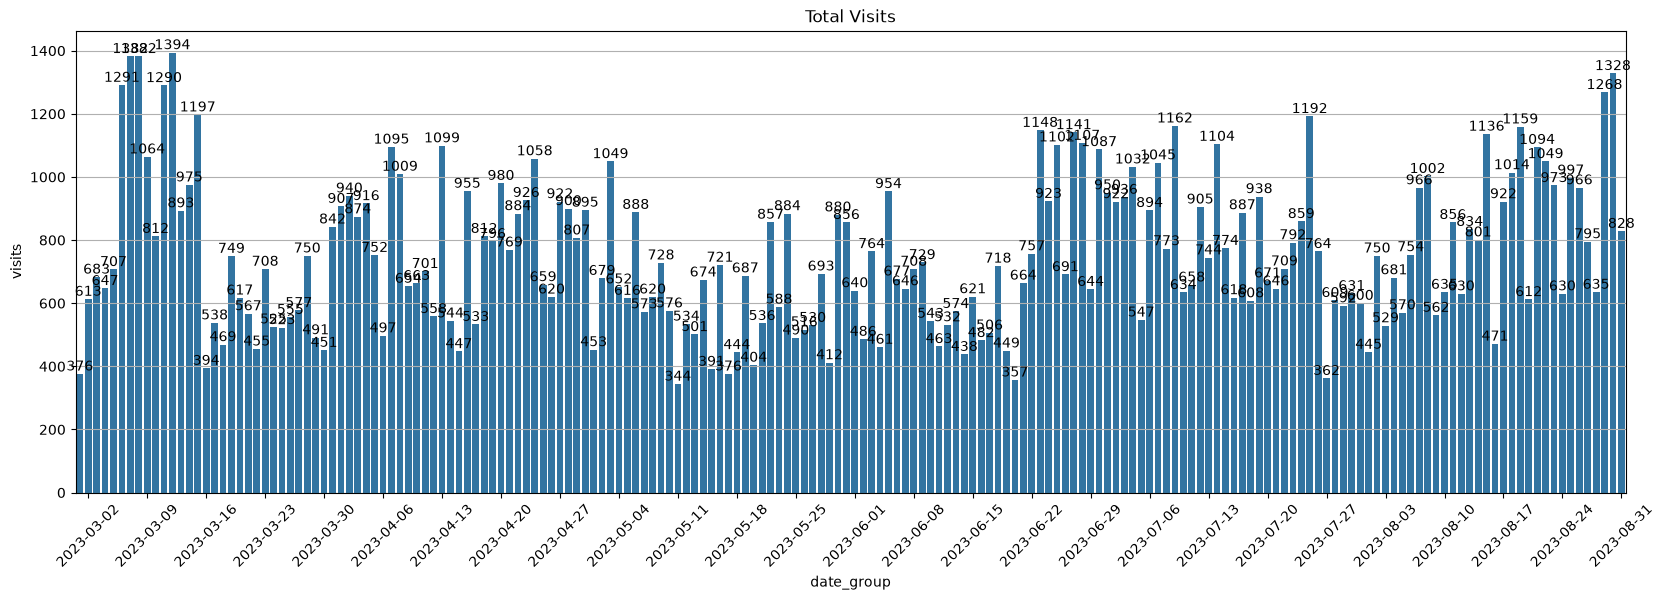

In [11]:
df_barplot = df_conversion.drop(columns= ['registrations', 'conversion'])

df_barplot = df_barplot.groupby('date_group').sum()

plt.figure(figsize=(20,6))

ax = sns.barplot(data= df_barplot, x= 'date_group', y= 'visits')
ax.set(xlabel= 'date_group', title= 'Total Visits')
ax.grid(axis='y')
ax.bar_label(ax.containers[0])
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45)

plt.savefig('./charts/total_visits.png')

- Visitors by platform (stacked)

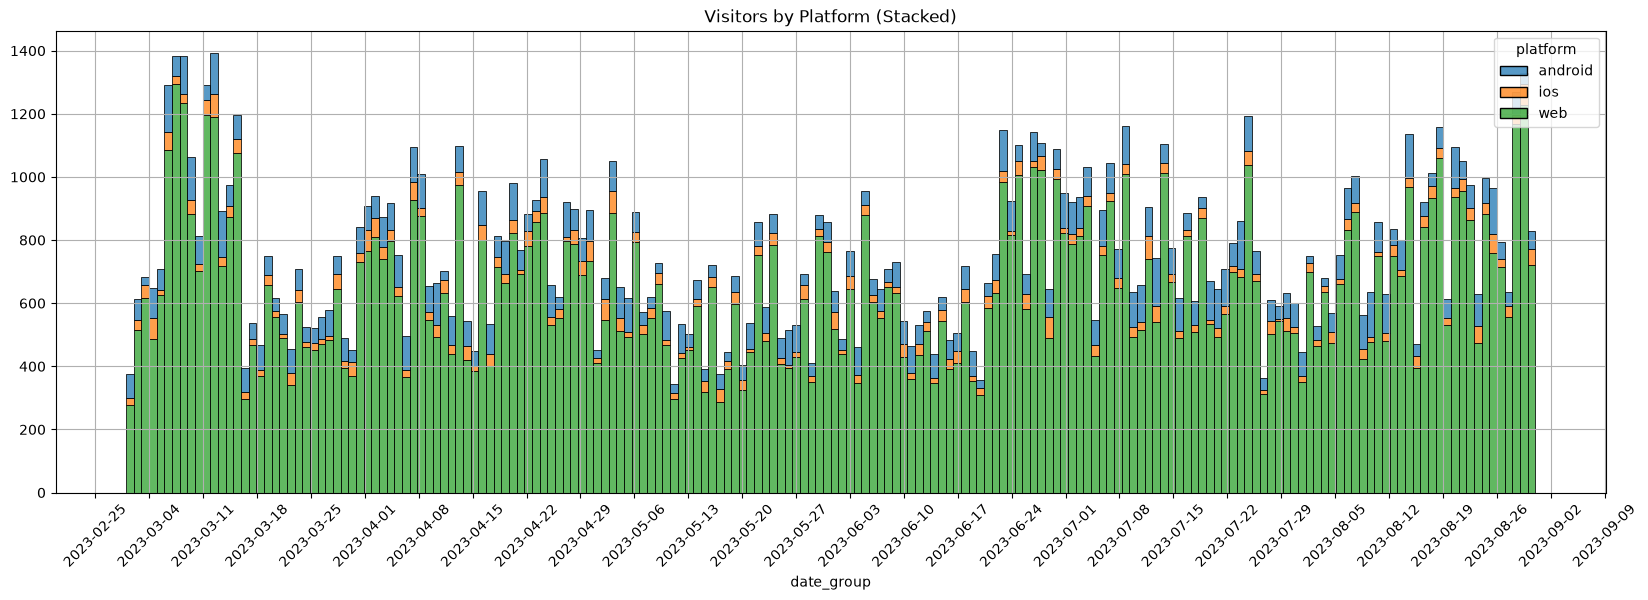

In [12]:
df_sbp = df_conversion.drop(columns= ['registrations', 'conversion'])

plt.figure(figsize= (20,6))


ax = sns.histplot(data= df_sbp, x= 'date_group', weights= 'visits', hue= 'platform', multiple= 'stack', bins= 184)
# именно так сделал график, потому что мне было проще просто бинс прописать
# чем три раза писать plt.barplot

ax.set(xlabel= 'date_group', ylabel='', title= 'Visitors by Platform (Stacked)')
ax.grid()

ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45)

sns.move_legend(ax, 'upper right')

plt.savefig('./charts/visitors_by_platform_stacked.png')

- Total registrations

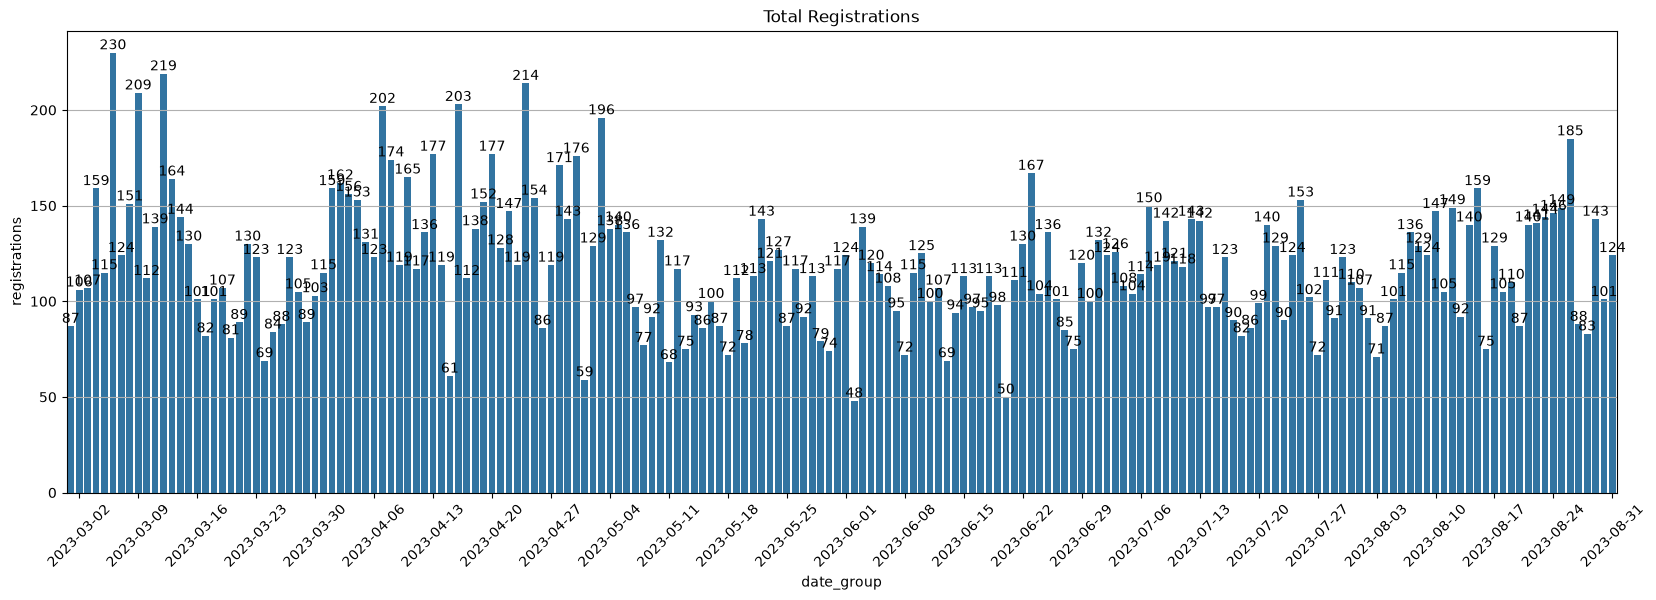

In [13]:
df_barplot = df_conversion.drop(columns= ['platform', 'visits', 'conversion'])
df_barplot = df_barplot.groupby('date_group').sum()

plt.figure(figsize=(20,6))

ax = sns.barplot(data= df_barplot, x= 'date_group', y= 'registrations')
ax.set(xlabel= 'date_group', title= 'Total Registrations')
ax.grid(axis='y')
ax.bar_label(ax.containers[0])
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45)

plt.savefig('./charts/total_registrations.png')

- Stacked registrations

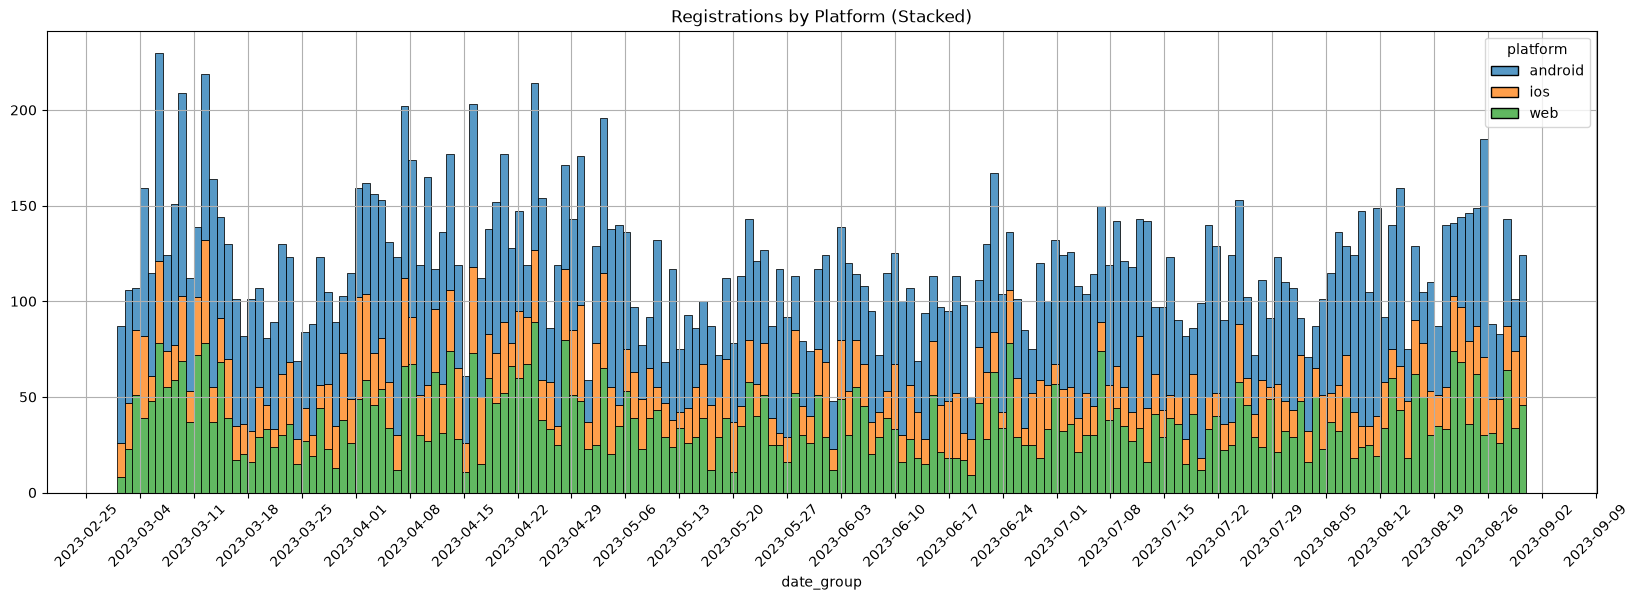

In [14]:
df_sbp = df_conversion.drop(columns= ['visits', 'conversion'])

plt.figure(figsize= (20,6))

ax = sns.histplot(data= df_sbp, x= 'date_group', weights= 'registrations', hue= 'platform', multiple= 'stack', bins= 184)
ax.set(xlabel= 'date_group', ylabel='', title= 'Registrations by Platform (Stacked)')
ax.grid()

ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=45)

plt.savefig('./charts/registrations_by_platform_stacked.png')

- Overall conversion

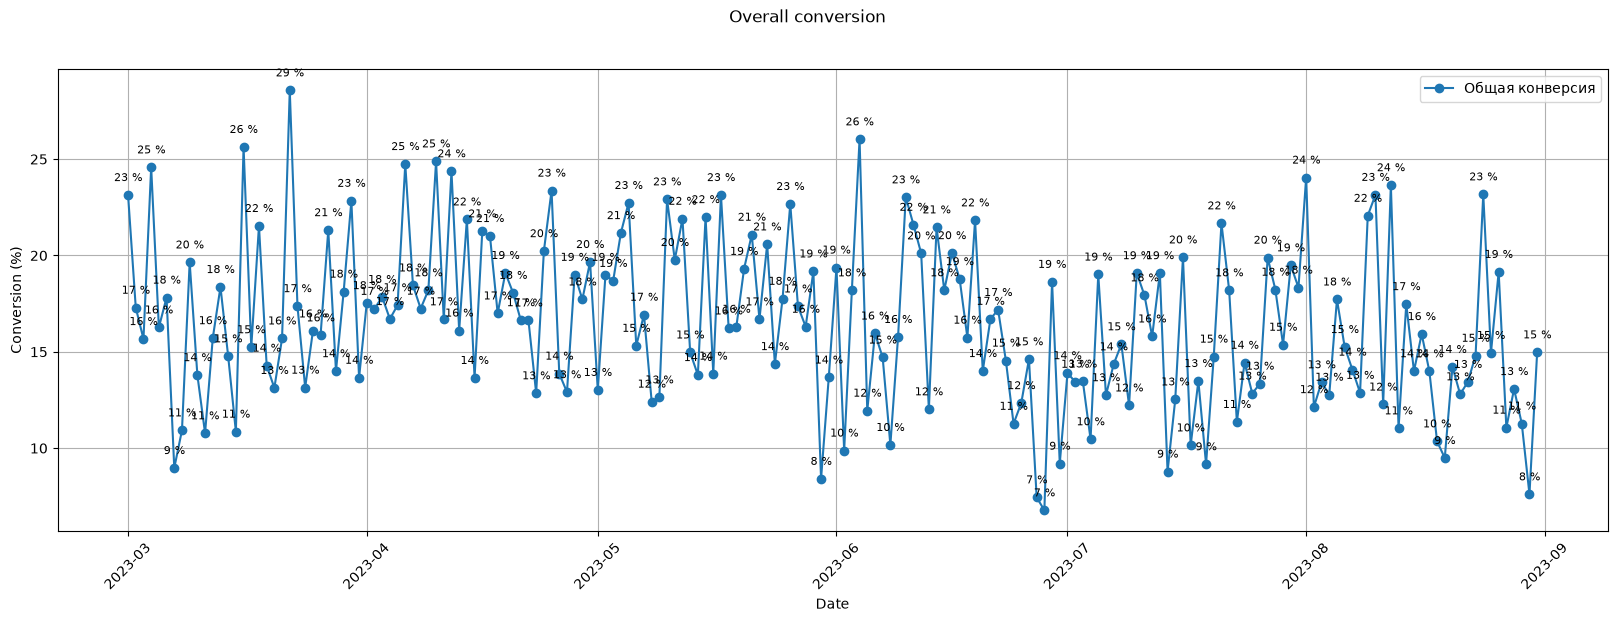

In [15]:
df_totconv = df_conversion
df_totconv = df_totconv.groupby('date_group').agg({
    'visits': 'sum',
    'registrations': 'sum'
}).reset_index()

df_totconv['Conversion'] = (df_totconv['registrations'] / df_totconv['visits']) * 100

fig, ax = plt.subplots(figsize= (20,6))
fig.suptitle('Overall conversion')

ax.plot(df_totconv['date_group'], df_totconv['Conversion'], marker= 'o', label= 'Общая конверсия')
ax.grid()
ax.legend()
plt.xticks(rotation=45)

line_label(ax, df_totconv['date_group'], df_totconv['Conversion'], symbol= '%')
ax.set(xlabel= 'Date', ylabel= 'Conversion (%)')

plt.savefig('./charts/overall_conversion.png')

- Conversion by platform

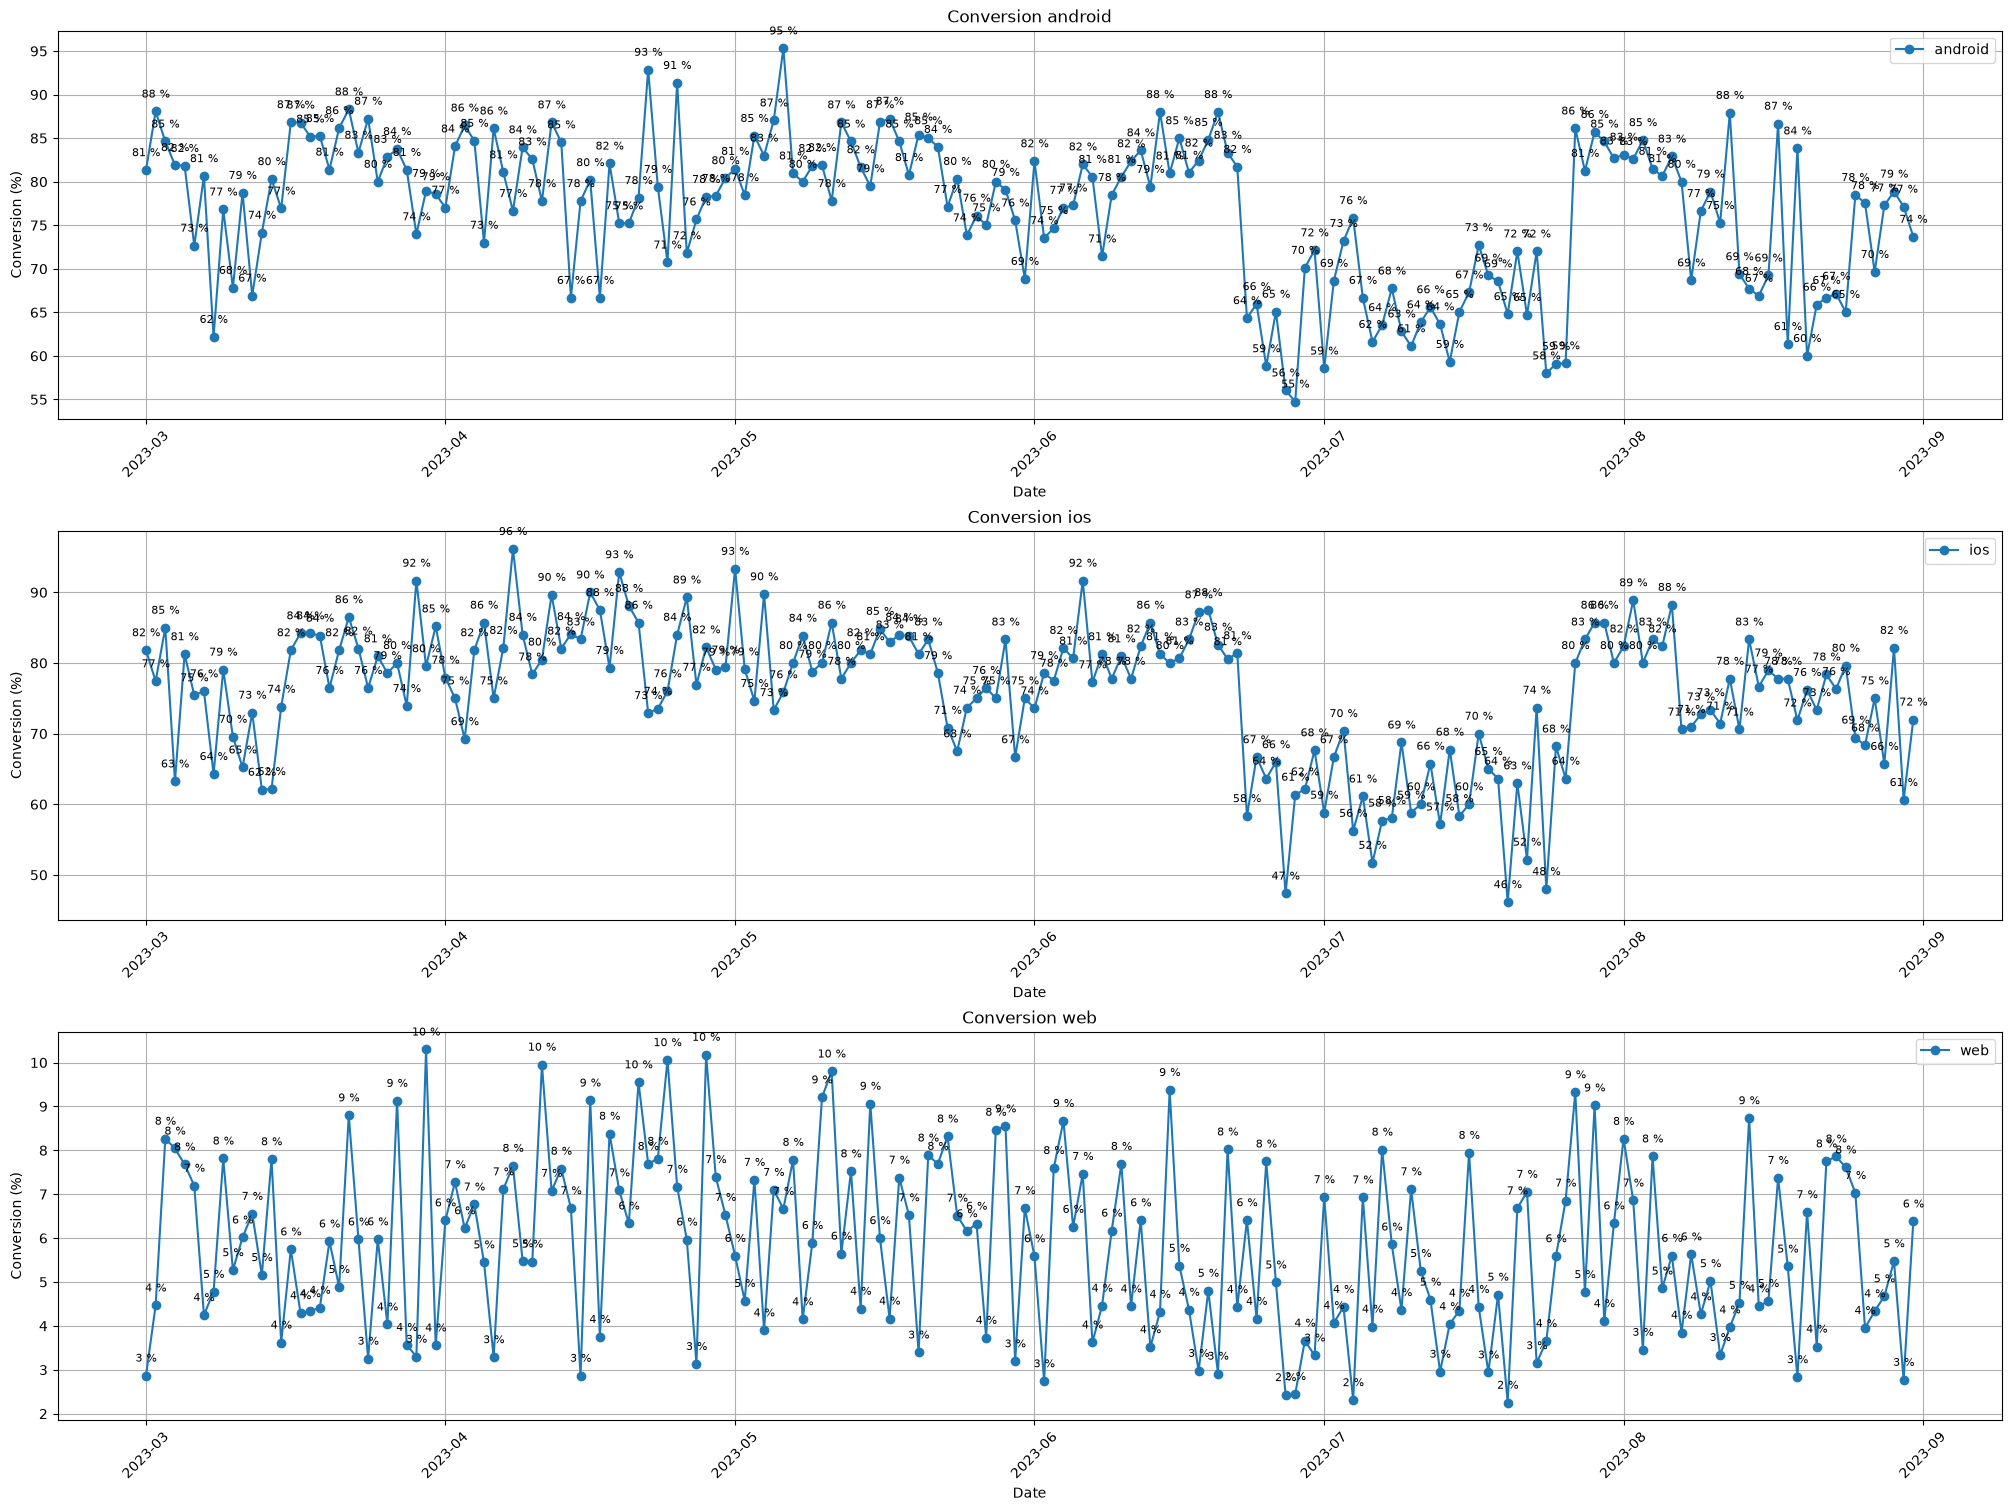

In [16]:
#data prep
df_platconv = df_conversion.drop(columns= 'conversion')
df_android = df_platconv[df_platconv['platform'] == 'android']
df_android['Conversion'] = (df_android['registrations'] / df_android['visits']) * 100

df_ios = df_platconv[df_platconv['platform'] == 'ios']
df_ios['Conversion'] = (df_ios['registrations'] / df_ios['visits']) * 100

df_web = df_platconv[df_platconv['platform'] == 'web']
df_web['Conversion'] = (df_web['registrations'] / df_web['visits']) * 100

#plotting
fig, axes = plt.subplots(3,1, layout= 'constrained')
fig.set_size_inches(20,15)

# andriod
axes[0].plot(df_android['date_group'], df_android['Conversion'], marker= 'o', label= 'android')
axes[0].grid()
axes[0].legend()
axes[0].set_title('Conversion android')
axes[0].tick_params(axis='x', labelrotation=45)
line_label(axes[0], df_android['date_group'], df_android['Conversion'], symbol= '%')
axes[0].set(xlabel= 'Date', ylabel= 'Conversion (%)')

#ios
axes[1].plot(df_ios['date_group'], df_ios['Conversion'], marker= 'o', label= 'ios')
axes[1].grid()
axes[1].legend()
axes[1].set_title('Conversion ios')
axes[1].tick_params(axis='x', labelrotation=45)
line_label(axes[1], df_ios['date_group'], df_ios['Conversion'], symbol= '%')
axes[1].set(xlabel= 'Date', ylabel= 'Conversion (%)')

#web
axes[2].plot(df_web['date_group'], df_web['Conversion'], marker= 'o', label= 'web')
axes[2].grid()
axes[2].legend()
axes[2].set_title('Conversion web')
axes[2].tick_params(axis='x', labelrotation=45)
line_label(axes[2], df_web['date_group'], df_web['Conversion'], symbol= '%')
axes[2].set(xlabel= 'Date', ylabel= 'Conversion (%)')

plt.savefig('./charts/conversion_per_platform.png')

- Aggregated ad campaign costs

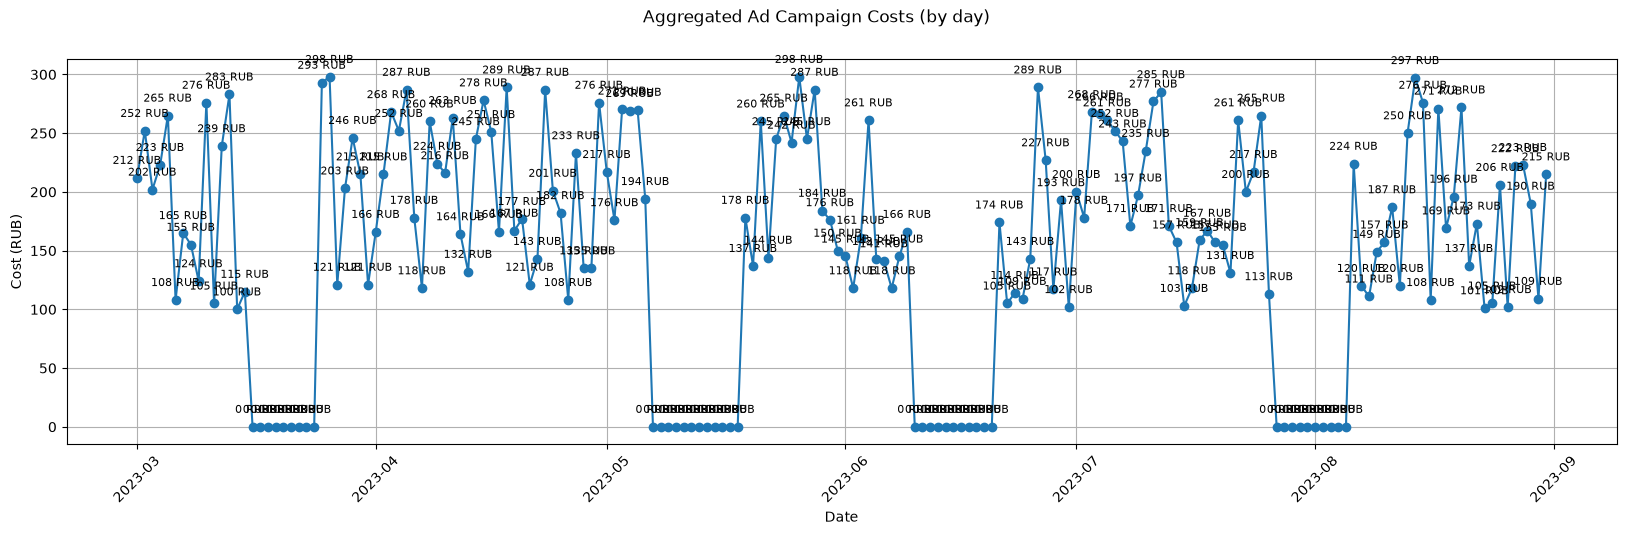

In [17]:
df_agg_ads = df_ads.groupby('date_group').agg({'cost': 'sum'}).reset_index()

fig, ax = plt.subplots()
fig.suptitle('Aggregated Ad Campaign Costs (by day)')
fig.set_size_inches(20,5)

ax.plot(df_agg_ads['date_group'], df_agg_ads['cost'], marker= 'o')
ax.grid()
ax.set_xlabel('Date')
ax.set_ylabel('Cost (RUB)')

plt.xticks(rotation=45)
line_label(ax, df_agg_ads['date_group'], df_agg_ads['cost'], symbol= 'RUB')

plt.savefig('./charts/advertising_costs.png')

- Visits and registrations during marketing active days

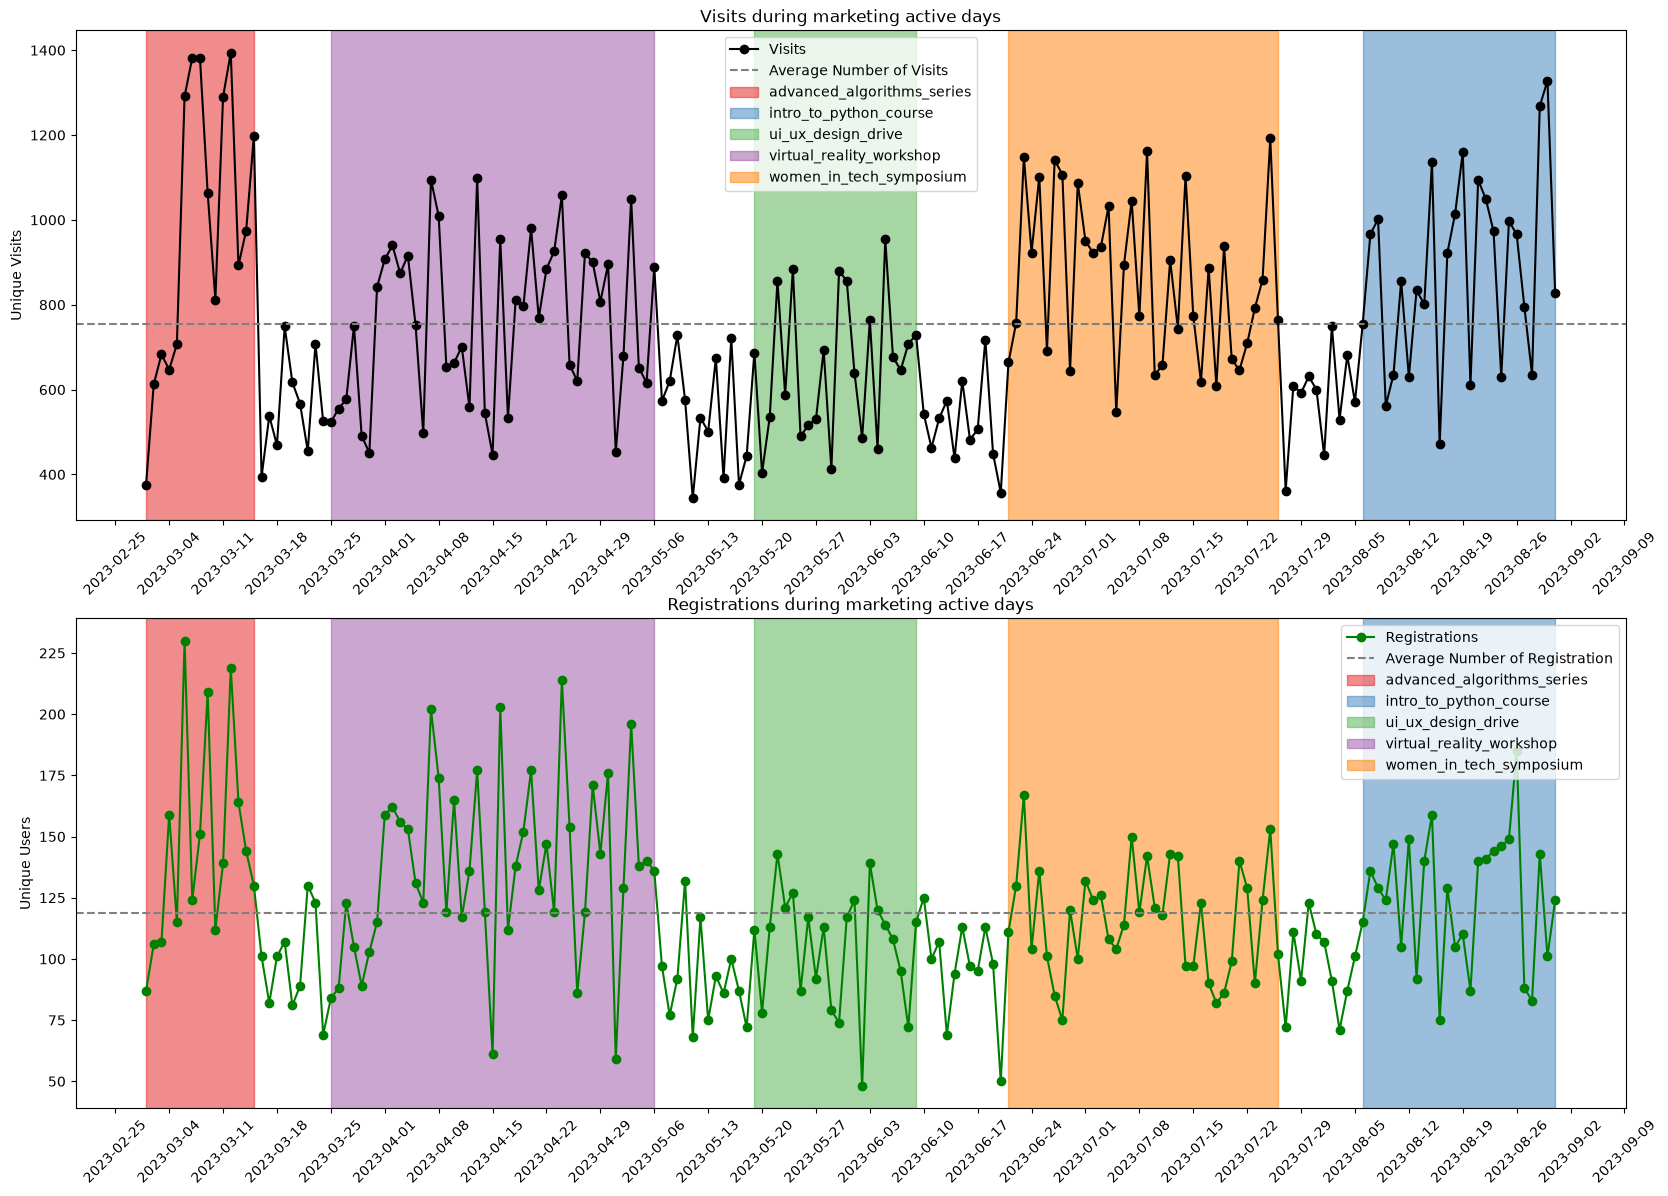

In [18]:
#prepping data
ranges = df_ads.groupby('utm_campaign')['date_group'].agg(['min', 'max'])

#beginnig da plot
fig, axes = plt.subplots(2,1)
fig.set_size_inches(20,14)

#plot_1
axes[0].plot(
    df_ads['date_group'],
    df_ads['visits'],
    marker= 'o',
    color= 'black',
    label= 'Visits'
)
axes[0].axhline(
    y= df_ads['visits'].mean(),
    linestyle= '--',
    color= 'gray',
    label= 'Average Number of Visits'
)

axes[0].set_title('Visits during marketing active days')
axes[0].set_ylabel('Unique Visits')
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=7))
axes[0].tick_params(axis='x', labelrotation=45)

colors = sns.color_palette("Set1", n_colors=len(ranges))

for i, (name, row) in enumerate(ranges.iterrows()):
    color = colors[i % len(colors)]
    axes[0].axvspan(row['min'], row['max'], color=color, alpha=0.5, label=name)

axes[0].legend()

#plot_2
axes[1].plot(
    df_ads['date_group'],
    df_ads['registrations'],
    marker= 'o',
    color= 'green',
    label= 'Registrations'
)
axes[1].axhline(
    y= df_ads['registrations'].mean(),
    linestyle= '--',
    color= 'gray',
    label= 'Average Number of Registration'
)

axes[1].set_title('Registrations during marketing active days')
axes[1].set_ylabel('Unique Users')
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=7))
axes[1].tick_params(axis='x', labelrotation=45)

colors = sns.color_palette("Set1", n_colors=len(ranges))

for i, (name, row) in enumerate(ranges.iterrows()):
    color = colors[i % len(colors)]
    axes[1].axvspan(row['min'], row['max'], color=color, alpha=0.5, label=name)

axes[1].legend(loc= 'upper right') #mb autotest expects the legend to be ordered differently here?


plt.savefig('./charts/visits_and_registrations_with_campaign_highlighting.png')
